In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/accidents.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst look:")
df.head()

Shape: (3000, 22)

Columns: ['State Name', 'City Name', 'Year', 'Month', 'Day of Week', 'Time of Day', 'Accident Severity', 'Number of Vehicles Involved', 'Vehicle Type Involved', 'Number of Casualties', 'Number of Fatalities', 'Weather Conditions', 'Road Type', 'Road Condition', 'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)', 'Driver Age', 'Driver Gender', 'Driver License Status', 'Alcohol Involvement', 'Accident Location Details']

First look:


,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


In [2]:
print("Null values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Null values:
State Name                       0
City Name                        0
Year                             0
Month                            0
Day of Week                      0
Time of Day                      0
Accident Severity                0
Number of Vehicles Involved      0
Vehicle Type Involved            0
Number of Casualties             0
Number of Fatalities             0
Weather Conditions               0
Road Type                        0
Road Condition                   0
Lighting Conditions              0
Traffic Control Presence       716
Speed Limit (km/h)               0
Driver Age                       0
Driver Gender                    0
Driver License Status          975
Alcohol Involvement              0
Accident Location Details        0
dtype: int64

Data types:
State Name                     object
City Name                      object
Year                            int64
Month                          object
Day of Week                    object
T

In [3]:
# Drop rows with too many nulls
df_clean = df.dropna(thresh=int(0.6 * len(df.columns)))

# Standardise column names
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(" ", "_")

print("Cleaned shape:", df_clean.shape)
df_clean.to_csv("../data/accidents_clean.csv", index=False)
print("Saved → data/accidents_clean.csv")

Cleaned shape: (3000, 22)
Saved → data/accidents_clean.csv


In [4]:
df_clean.head()

,state_name,city_name,year,month,day_of_week,time_of_day,accident_severity,number_of_vehicles_involved,vehicle_type_involved,number_of_casualties,...,road_type,road_condition,lighting_conditions,traffic_control_presence,speed_limit_(km/h),driver_age,driver_gender,driver_license_status,alcohol_involvement,accident_location_details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


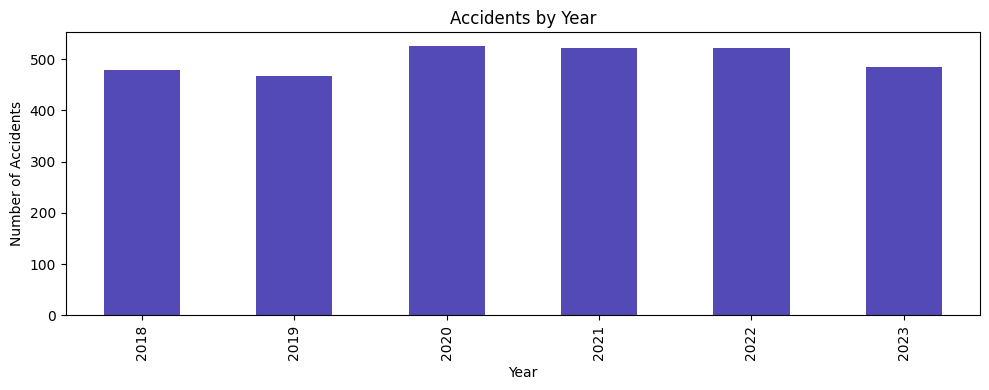

In [5]:
plt.figure(figsize=(10, 4))

# Find the year column (already standardized)
year_col = [c for c in df_clean.columns if "year" in c][0]

# Plot accidents per year
df_clean[year_col].value_counts().sort_index().plot(
    kind="bar", color="#534AB7"
)

plt.title("Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.tight_layout()

# Save chart
plt.savefig("../data/chart_yearly.png")
plt.show()

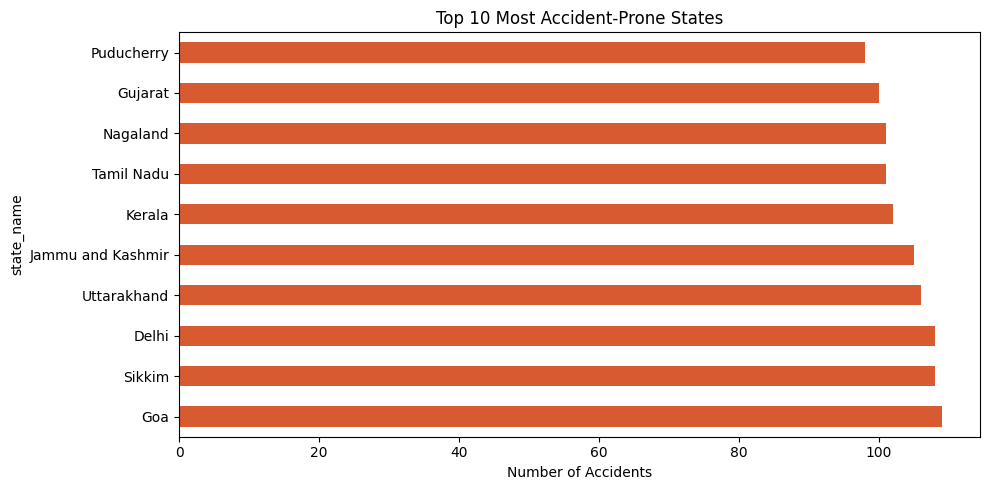

In [6]:
# State column
state_col = [c for c in df_clean.columns if "state" in c][0]

# Count accidents per state
top_states = df_clean[state_col].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_states.plot(kind="barh", color="#D85A30")
plt.title("Top 10 Most Accident-Prone States")
plt.xlabel("Number of Accidents")
plt.tight_layout()

# Save chart
plt.savefig("../data/chart_states.png")
plt.show()

In [7]:
# Check if lat/lon columns exist
lat_cols = [c for c in df_clean.columns if "lat" in c.lower()]
lon_cols = [c for c in df_clean.columns if "lon" in c.lower()]

if lat_cols and lon_cols:
    print("Lat/Lon found:", lat_cols, lon_cols)
    df_clean = df_clean.rename(columns={lat_cols[0]: "latitude",
                                        lon_cols[0]: "longitude"})
else:
    print("No lat/lon found — adding state centroids")
    STATE_COORDS = {
        "Rajasthan": (27.0238, 74.2179),
        "Maharashtra": (19.7515, 75.7139),
        "Uttar Pradesh": (26.8467, 80.9462),
        "Tamil Nadu": (11.1271, 78.6569),
        "Karnataka": (15.3173, 75.7139),
        "Gujarat": (22.2587, 71.1924),
        "Madhya Pradesh": (22.9734, 78.6569),
        "Bihar": (25.0961, 85.3131),
        "West Bengal": (22.9868, 87.8550),
        "Andhra Pradesh": (15.9129, 79.7400)
    }

    df_clean["latitude"] = df_clean[state_col].map(
        lambda s: STATE_COORDS.get(s, (20.5937, 78.9629))[0]
    )
    df_clean["longitude"] = df_clean[state_col].map(
        lambda s: STATE_COORDS.get(s, (20.5937, 78.9629))[1]
    )

# Save updated CSV
df_clean.to_csv("../data/accidents_clean.csv", index=False)
print("Updated CSV saved with lat/lon")

No lat/lon found — adding state centroids
Updated CSV saved with lat/lon


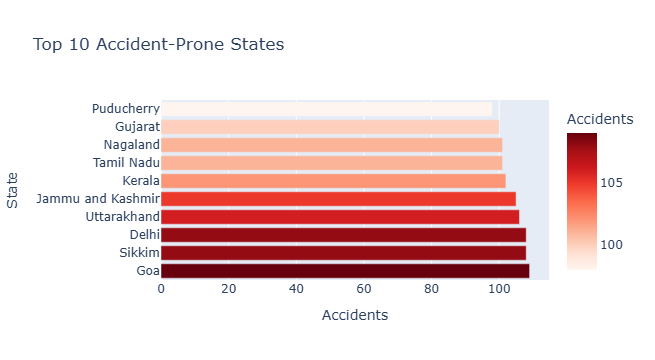

In [8]:
import plotly.express as px
import plotly.graph_objects as go

df_acc = pd.read_csv("../data/accidents_clean.csv")
df_iot = pd.read_csv("../data/merged_data.csv")

# Chart 1: Accident heatmap by state
state_col = [c for c in df_acc.columns if "state" in c][0]
state_counts = df_acc[state_col].value_counts().reset_index()
state_counts.columns = ["State", "Accidents"]

fig1 = px.bar(state_counts.head(10), x="Accidents", y="State",
              orientation="h", title="Top 10 Accident-Prone States",
              color="Accidents", color_continuous_scale="Reds")
fig1.write_html("../data/chart_states.html")
fig1.show()

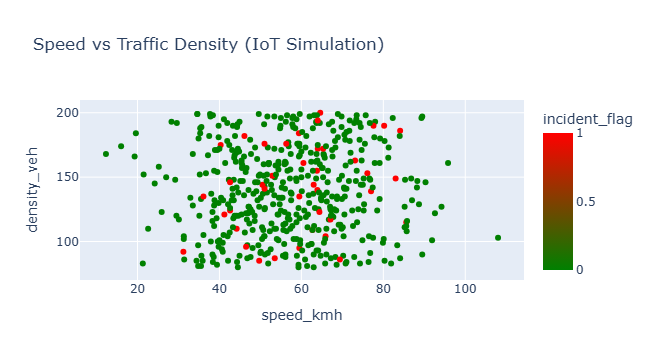

In [9]:
fig2 = px.scatter(df_iot, x="speed_kmh", y="density_veh",
                  color="incident_flag",
                  hover_data=["highway", "condition"],
                  title="Speed vs Traffic Density (IoT Simulation)",
                  color_continuous_scale=["green", "red"])
fig2.write_html("../data/chart_iot.html")
fig2.show()

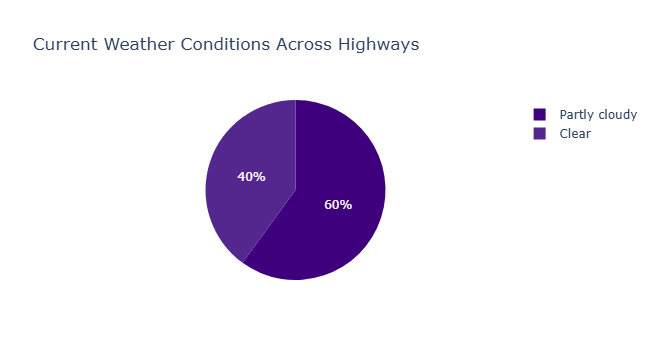

In [10]:
fig3 = px.pie(df_iot, names="condition",
              title="Current Weather Conditions Across Highways",
              color_discrete_sequence=px.colors.sequential.Purples_r)
fig3.write_html("../data/chart_weather.html")
fig3.show()